In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pysam
from pyfaidx import Fasta

from pyformME import utils_informME
from pyformME import io_informME
from pyformME import a_refCpGs_process
from pyformME import a_fasta2CpG

from pyformME import b_bam_process
from pyformME import b_bam2MEmat

from pyformME import c_MEmat_process
from pyformME import c_ising_model
from pyformME import c_informME

# Test fasta to df CpGs

In [3]:
# Load the FASTA (and its index)
fasta_path = "/Users/tnegre/Desktop/trial_informme/mm10_forWGBS/GRCm38.primary_assembly.genome.fa"
fa = io_informME.load_fasta(fasta_path)  # Will automatically use the .fai file

In [4]:
fa.keys( 
)

odict_keys(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chrX', 'chrY', 'chrM', 'GL456210.1', 'GL456211.1', 'GL456212.1', 'GL456213.1', 'GL456216.1', 'GL456219.1', 'GL456221.1', 'GL456233.1', 'GL456239.1', 'GL456350.1', 'GL456354.1', 'GL456359.1', 'GL456360.1', 'GL456366.1', 'GL456367.1', 'GL456368.1', 'GL456370.1', 'GL456372.1', 'GL456378.1', 'GL456379.1', 'GL456381.1', 'GL456382.1', 'GL456383.1', 'GL456385.1', 'GL456387.1', 'GL456389.1', 'GL456390.1', 'GL456392.1', 'GL456393.1', 'GL456394.1', 'GL456396.1', 'JH584292.1', 'JH584293.1', 'JH584294.1', 'JH584295.1', 'JH584296.1', 'JH584297.1', 'JH584298.1', 'JH584299.1', 'JH584300.1', 'JH584301.1', 'JH584302.1', 'JH584303.1', 'JH584304.1'])

Try sub functions

In [5]:
df_Cs_chr1 = a_refCpGs_process.get_Cs_chr(fasta_file = fa, chr_name = 'chr1')
df_Cs_chr1.head()

,position,next_base
0,3000003,T
1,3000009,T
2,3000023,T
3,3000047,T
4,3000050,T


In [6]:
del(df_Cs_chr1)

In [7]:
df_CpGs_chr1 = a_refCpGs_process.get_CpGs_chr(fasta_file = fa, chr_name = 'chr1')
df_CpGs_chr1.head()

,position,next_base
0,3000827,G
1,3001007,G
2,3001018,G
3,3001277,G
4,3001629,G


In [8]:
df_CpGs_chr1 = a_refCpGs_process.get_CpGs_distance(df_CpGs_chr1)
df_CpGs_chr1.head()

,position,next_base,distance_to_next
0,3000827,G,180.0
1,3001007,G,11.0
2,3001018,G,259.0
3,3001277,G,352.0
4,3001629,G,1597.0


In [9]:
df_CpGs_chr1 = a_refCpGs_process.get_CpGs_density(df_CpGs_chr1, window=1000)
df_CpGs_chr1.head()

,position,next_base,distance_to_next,density
0,3000827,G,180.0,0.004
1,3001007,G,11.0,0.004
2,3001018,G,259.0,0.004
3,3001277,G,352.0,0.005
4,3001629,G,1597.0,0.002


Try main function

In [10]:
CpGs_save_path="/Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg"


In [11]:
# Generate a CpGslocation csv file for each chromosome.
# Contains a column position, next_base, distance_to_next, density

df_CpGs_chrs = a_fasta2CpG.fasta2CpGs(fasta_file = fa,  
                                    save_path = CpGs_save_path,
                                    chr_name_list=list(fa.keys()),
                                    window=1000)
del(df_CpGs_chrs)

Process chr1
CpGs site positions, distance and density computed for chr1
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr1.csv
Process chr2
CpGs site positions, distance and density computed for chr2
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr2.csv
Process chr3
CpGs site positions, distance and density computed for chr3
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr3.csv
Process chr4
CpGs site positions, distance and density computed for chr4
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr4.csv
Process chr5
CpGs site positions, distance and density computed for chr5
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr5.csv
Process chr6
CpGs site positions, distance and density computed for chr6
Saved in /Users/tnegre/Desktop/epic_msus/results/test_fasta_cpg/CpGslocation_chr6.csv
Process chr7
CpGs site positions, distance and

# Test some io methods

In [12]:
df_CpGs_chr1 = io_informME.load_CpGs_chr(CpG_folder_path = CpGs_save_path, 
                                         chr_name = 'chr1')
df_CpGs_chr1.head()

,position,next_base,distance_to_next,density
0,3000827,G,180.0,0.004
1,3001007,G,11.0,0.004
2,3001018,G,259.0,0.004
3,3001277,G,352.0,0.005
4,3001629,G,1597.0,0.002


In [14]:
df_CpGs_all_chrs = io_informME.load_CpGs(CpG_folder_path = CpGs_save_path)
print(list(df_CpGs_all_chrs.keys())[:5])
df_CpGs_all_chrs[list(df_CpGs_all_chrs.keys())[0]]


['JH584294.1', 'GL456239.1', 'GL456378.1', 'GL456385.1', 'GL456387.1']


,position,next_base,distance_to_next,density
0,50,G,58.0,0.008
1,108,G,161.0,0.009
2,269,G,4.0,0.018
3,273,G,50.0,0.018
4,323,G,163.0,0.020
...,...,...,...,...
2300,191356,G,18.0,0.008
2301,191374,G,433.0,0.007
2302,191807,G,25.0,0.006
2303,191832,G,16.0,0.006


In [15]:
del(df_CpGs_all_chrs)

In [17]:
bam_path_oocyte = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam"
pheno_path = "/Users/tnegre/Desktop/trial_informme/oocyte/pheno_methylation.csv"
output_bam_path = "/Users/tnegre/Desktop/epic_msus/results/test_oocyte_bam"

In [ ]:

df_bam = io_informME.store_rename_files(input_folder_path = bam_path_oocyte, 
                                    pheno_path = pheno_path, 
                                    pheno_label_list = ['Group'], 
                                    suffix = "", 
                                    output_folder_path = output_bam_path)

df_bam.head()

In [18]:
df_bam = io_informME.get_df_files(base_folder_path = output_bam_path, 
                                  pheno_label_list = ['Group'],
                                    suffix = '.bam')
df_bam.head()

,file_name,file_path,Group
0,PM_9_3-r1_trimmed_bismark_bt2_sm.bam,/Users/tnegre/Desktop/epic_msus/results/test_o...,MSUS
1,PM_24_3-r1_trimmed_bismark_bt2_sm.bam,/Users/tnegre/Desktop/epic_msus/results/test_o...,MSUS
2,PM_4_3-r1_trimmed_bismark_bt2_sm.bam,/Users/tnegre/Desktop/epic_msus/results/test_o...,MSUS
3,PM_22_2-r1_trimmed_bismark_bt2_sm.bam,/Users/tnegre/Desktop/epic_msus/results/test_o...,MSUS
4,PM_6_3-r2_trimmed_bismark_bt2_sm.bam,/Users/tnegre/Desktop/epic_msus/results/test_o...,MSUS


# Test Bam to ME mat

The preprocess steps of the ref cpgs

In [19]:
region_lims_pos = a_refCpGs_process._get_chr_regions(df_CpGs = df_CpGs_chr1, 
                                            region_length = 3000)
region_lims_pos

array([  3000827,   3003827,   3006827, ..., 195366827, 195369827,
       195371432], shape=(64125,))

In [20]:
df_CpGs_chr1_per_region = a_refCpGs_process.get_CpGs_per_region(df_CpGs = df_CpGs_chr1,
                                                                region_length = 3000,
                                                                min_n_CpGs_per_region = 0)
region_lim, df_CpGs_region = next(iter(df_CpGs_chr1_per_region))
print(region_lim)
df_CpGs_region.head()

[3000827, 3003827)


,position,next_base,distance_to_next,density,region
0,3000827,G,180.0,0.004,"[3000827, 3003827)"
1,3001007,G,11.0,0.004,"[3000827, 3003827)"
2,3001018,G,259.0,0.004,"[3000827, 3003827)"
3,3001277,G,352.0,0.005,"[3000827, 3003827)"
4,3001629,G,1597.0,0.002,"[3000827, 3003827)"


In [91]:
type(region_lim)

pandas._libs.interval.Interval

In [23]:
df_CpGs_chr1_per_region.get_group(region_lim)

,position,next_base,distance_to_next,density,region
0,3000827,G,180.0,0.004,"[3000827, 3003827)"
1,3001007,G,11.0,0.004,"[3000827, 3003827)"
2,3001018,G,259.0,0.004,"[3000827, 3003827)"
3,3001277,G,352.0,0.005,"[3000827, 3003827)"
4,3001629,G,1597.0,0.002,"[3000827, 3003827)"
5,3003226,G,113.0,0.006,"[3000827, 3003827)"
6,3003339,G,40.0,0.006,"[3000827, 3003827)"
7,3003379,G,203.0,0.006,"[3000827, 3003827)"
8,3003582,G,58.0,0.008,"[3000827, 3003827)"
9,3003640,G,81.0,0.008,"[3000827, 3003827)"


The preprocess step of the reads

In [40]:
bam_path_oocyte_r1 = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_24_3-r1_trimmed_bismark_bt2_sm.bam"
bam_path_oocyte_r2 = "/Users/tnegre/Desktop/trial_informme/oocyte/oocyte_indexed_bam/PM_24_3-r2_trimmed_bismark_bt2_sm.bam"

bam_path_sperm = "/Users/tnegre/Desktop/trial_informme/sperm/bam_example/MSUS23-F1-2_S20_R1_val_1_bismark_bt2_pe_sm.bam"

Test utils function to convert chr name

In [54]:
chr_name_list = ['chr1', 1, '1', 'chrX', 'X', 'chrM', 'M', 'MT']
for chr_name in chr_name_list:
    chr_ref = utils_informME.chr2refseq(chr_name)
    print(chr_ref)

NC_000067.6
NC_000067.6
NC_000067.6
NC_000086.7
NC_000086.7
NC_005089.1
NC_005089.1
NC_005089.1


In [56]:
chr_name = 'chr1'
chr_ref = utils_informME.chr2refseq(chr_name)

In [41]:
bam_r1 = io_informME.load_bam(bam_file_path=bam_path_oocyte_r1)
bam_r2 = io_informME.load_bam(bam_file_path=bam_path_oocyte_r2)

In [43]:
reads = list(bam_r1.fetch(chr_ref, 5000180, 5001000))


In [44]:
read = reads[2]
read.get_reference_positions()

[5000244,
 5000245,
 5000246,
 5000247,
 5000248,
 5000249,
 5000250,
 5000251,
 5000252,
 5000253,
 5000254,
 5000255,
 5000256,
 5000257,
 5000258,
 5000259,
 5000260,
 5000261,
 5000262,
 5000263,
 5000264,
 5000265,
 5000266,
 5000267,
 5000268,
 5000269,
 5000270,
 5000271,
 5000272,
 5000273,
 5000274,
 5000275,
 5000276,
 5000277,
 5000278,
 5000279,
 5000280,
 5000281,
 5000282,
 5000283,
 5000284,
 5000285,
 5000286,
 5000287,
 5000288,
 5000289,
 5000290,
 5000291,
 5000292,
 5000293,
 5000294,
 5000295,
 5000296,
 5000297,
 5000298,
 5000299,
 5000300,
 5000301,
 5000302,
 5000303,
 5000304,
 5000305,
 5000306,
 5000307,
 5000308,
 5000309,
 5000310,
 5000311,
 5000312,
 5000313,
 5000314,
 5000315,
 5000316,
 5000317,
 5000318,
 5000319,
 5000320,
 5000321,
 5000322,
 5000323,
 5000324,
 5000325,
 5000326,
 5000327,
 5000328,
 5000329,
 5000330,
 5000331,
 5000332,
 5000333,
 5000334,
 5000335,
 5000336,
 5000337,
 5000338,
 5000339,
 5000340,
 5000341,
 5000342,
 5000343,


In [37]:
region_lim

Interval(3000827, 3003827, closed='left')

In [59]:
# Loop through your regions
start = int(region_lim.left)
end = int(region_lim.right)
region_str = f"{chr_ref}:{start}-{end}"
# PySAM fetch: note end is exclusive
r1s = bam_r1.fetch(chr_ref, start, end)
r2s = bam_r2.fetch(chr_ref, start, end)
r1_list = list(r1s)
r2_list = list(r2s)
for r1 in r1_list:
    seq = r1.query_sequence  # Get the sequence
    xm = r1.get_tag("XM") if r1.has_tag("XM") else None  # Get the XM tag (if it exists)
    print(r1.reference_name)
    print(r1.reference_start)
    print(r1.reference_end)

    print("reversed", r1.is_reverse)
    print("is_paired", r1.is_paired)
    print("is_proper_pair", r1.is_proper_pair)
    print("is_read1", r1.is_read1)

    ref_seq = utils_informME.get_refseq(fasta_file= fa,
                               chr_name = chr_name,
                                 ref_pos =[r1.reference_start, r1.reference_end])
    print(f"{ref_seq}")
    print(f"{seq},")
    print(f"{xm}")

NC_000067.6
3000781
3000902
reversed True
is_paired False
is_proper_pair False
is_read1 False
TTGGCTTTCTATTATTTATGCTGTTATTGAAGATCAGCCTTAGTCCGTAGTTATCTGAAAGGATGCATGGGAAAATTTCAATATTTTTGTATCTGTTGAGGACTTTTTGTGAGTGACTATAT
TTAACTTCCTATTATTTATATTATTATTAAAAATCAACCTTAATCCATAATTATCTAAAAAAATACATAAAAAATTTCAATATTTTTATATCTATTAAAAACTTTTTATAAATAACTATA,
..hh...............h..x.....h..h....x.....h...z..h......x...hh..h...hh.................h.....x..h.hh.......h.h.h.h......
NC_000067.6
3000781
3000902
reversed True
is_paired False
is_proper_pair False
is_read1 False
TTGGCTTTCTATTATTTATGCTGTTATTGAAGATCAGCCTTAGTCCGTAGTTATCTGAAAGGATGCATGGGAAAATTTCAATATTTTTGTATCTGTTGAGGACTTTTTGTGAGTGACTATAT
TTAACTTCCTATTATTTATATTATTATTAAAAATCAACCTTAATCCATAATTATCTAAAAAAATACATAAAAAATTTCAATATTTTTATATCTATTAAAAACTTTTTATAAATAACTATA,
..hh...............h..x.....h..h....x.....h...z..h......x...hh..h...hh.................h.....x..h.hh.......h.h.h.h......
NC_000067.6
3000781
3000902
reversed True
is_paired False
is_proper_pair False
i

In [65]:
reads_filtered = b_bam_process.deduplicate_reads(r1_list)

for r in list(reads_filtered):
    print(r)

E00526:575:HJLY3CCX2:7:1115:26260:54752_1:N:0:AGTTCC	16	NC_000067.6	3000782	0	68M1D52M	*	0	0	TTAACTTCCTATTATTTATATTATTATTAAAAATCAACCTTAATCCATAATTATCTAAAAAAATACATAAAAAATTTCAATATTTTTATATCTATTAAAAACTTTTTATAAATAACTATA	array('B', [37, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41])	[('NM', 28), ('MD', '2G0G3T11G0C1G5G2G4G5G3G2G6G3G0G2G3^G0G0G17G5G2G1G0G7G1G1G1G6'), ('XM', '..hh...............h..x.....h..h....x.....h...z..h......x...hh..h...hh.................h.....x..h.hh.......h.h.h.h......'), ('XR', 'GA'), ('XG', 'GA')]
E00526:575:HJLY3CCX2:7:1222:4624:46701_1:N:0:AGT

In [66]:
bam_reads_large = r1_list * 1000  # Now it has 30 reads (3 × 10)


In [67]:
import time


In [70]:
start = time.time()
ME_sparse_1 = b_bam2MEmat.reads2MEmat2(bam_reads = bam_reads_large,
                 df_CpGs_region = df_CpGs_region)
print("Elapsed:", time.time() - start)

Elapsed: 0.0323331356048584


In [71]:
start = time.time()
ME_sparse_2 = b_bam2MEmat.reads2MEmat(bam_reads = bam_reads_large,
                 df_CpGs_region = df_CpGs_region)
print("Elapsed:", time.time() - start)


Elapsed: 0.03128385543823242


In [72]:
ME_sparse = b_bam2MEmat.reads2MEmat2(bam_reads = reads_filtered,

                 df_CpGs_region = df_CpGs_region)

In [73]:
ME_matrix = ME_sparse.toarray()
ME_matrix

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [75]:
df_ME_mats = b_bam2MEmat.bam2MEmats(bam_file_path = bam_path_oocyte,
                        paired_ends = False,
                        min_phred_score = 10,
                        df_CpGs_per_region = df_CpGs_chr1_per_region,
                        chr_name = chr_name)

df_ME_mats.head()


62022 regions processed over 64124


,region,MEmat
0,NC_000067.6:3000827-3003827,<Compressed Sparse Row sparse matrix of dtype ...
1,NC_000067.6:3003827-3006827,<Compressed Sparse Row sparse matrix of dtype ...
2,NC_000067.6:3006827-3009827,<Compressed Sparse Row sparse matrix of dtype ...
3,NC_000067.6:3009827-3012827,<Compressed Sparse Row sparse matrix of dtype ...
4,NC_000067.6:3012827-3015827,<Compressed Sparse Row sparse matrix of dtype ...


In [ ]:
del(df_ME_mats)

Test the main function 

In [ ]:
bam_dir = "/Users/tnegre/Desktop/epic_msus/results/test_oocyte_bam"
save_path = "/Users/tnegre/Desktop/epic_msus/results/test_oocyte_mat"
b_bam2MEmat.get_MEmats_chr(bam_folder_path = bam_dir,
                            pheno_label_list = ['Group'],
                            suffix = ".bam",
                            paired_ends = False,
                            min_phred_score = 10,
                            CpGs_ref_folder_path = CpGs_save_path,
                            chr_name = chr_name,
                            region_length = 3000,
                            save_path = save_path,
                            min_n_CpGs_per_region=10,
                )

Load mat 

In [13]:
MEmat_path = "/home/tnegre/Desktop/matriline_project/matriline/epic_matriline_analysis/oocyte_MSUS37_DK/scWGBS/03_pyformME/03_merged_MEmat/Control/chr1/Control_chr1_oocyte_merged_MEmats.pkl"

df_MEmat = io_informME.load_MEmat(MEmat_path)

In [14]:
df_MEmat.iloc[0]["MEmat"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58 stored elements and shape (35, 12)>

In [15]:
MEmat_path = "/home/tnegre/Desktop/matriline_project/matriline/epic_matriline_analysis/oocyte_MSUS37_DK/scWGBS/03_pyformME/03_merged_MEmat_old/Control/chr1/Control_chr1_oocyte_merged_MEmats.pkl"

df_MEmat = io_informME.load_MEmat(MEmat_path)

In [16]:
df_MEmat.iloc[0]["MEmat"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58 stored elements and shape (35, 12)>

Test how it looks like

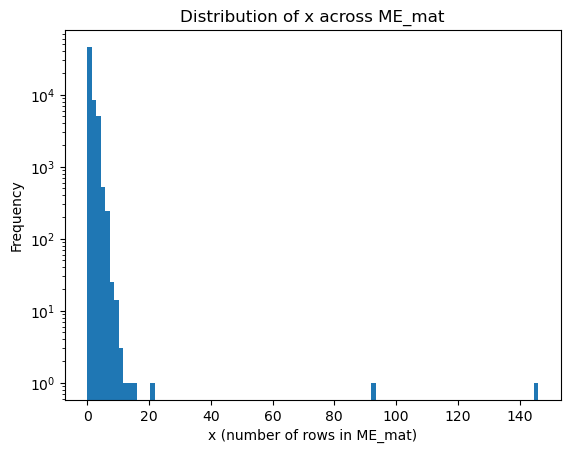

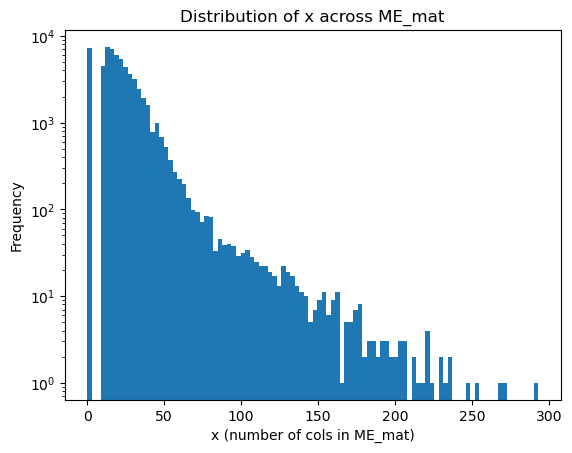

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Let's assume your DataFrame is called df and ME_mat column contains sparse matrices

# Compute number of rows for each ME_mat
df_MEmat['n_reads'] = df_MEmat['ME_mat'].apply(lambda mat: mat.shape[0])

# Plot the distribution
plt.figure()
plt.hist(df_MEmat['n_reads'], bins=100)
plt.yscale('log')
plt.xlabel('x (number of rows in ME_mat)')
plt.ylabel('Frequency')
plt.title('Distribution of x across ME_mat')
plt.show()

# Compute number of rows for each ME_mat
df_MEmat['n_CpGs'] = df_MEmat['ME_mat'].apply(lambda mat: mat.shape[1])

# Plot the distribution
plt.figure()
plt.hist(df_MEmat['n_CpGs'], bins=100)
plt.yscale('log')
plt.xlabel('x (number of cols in ME_mat)')
plt.ylabel('Frequency')
plt.title('Distribution of x across ME_mat')
plt.show()


Test merge ME mats

In [81]:
import io_informME
mat_base_folder_path = "/Users/tnegre/Desktop/epic_msus/results/test_oocyte_mat"

In [82]:
df_MEmats_ctrl  = io_informME.load_MEmats_pheno(base_folder_path = mat_base_folder_path,
                                pheno_label_list = ['Group'],
                                pheno_values_dict = {'Group': 'Control'},
                                chr_name = "chr1",
                                )

In [83]:
df_MEmats_ctrl.head()

,file_name,file_path,Group,MEmats
20,Control_ref_chr1_PM_3_3-r2_trimmed_bismark_bt2...,/Users/tnegre/Desktop/epic_msus/results/test_o...,Control,region \ 0 ...
21,Control_ref_chr1_PM_3_2-r1_trimmed_bismark_bt2...,/Users/tnegre/Desktop/epic_msus/results/test_o...,Control,region \ 0 ...
22,Control_ref_chr1_PM_14_2-r2_trimmed_bismark_bt...,/Users/tnegre/Desktop/epic_msus/results/test_o...,Control,region \ 0 ...
23,Control_ref_chr1_PM_14_3-r1_trimmed_bismark_bt...,/Users/tnegre/Desktop/epic_msus/results/test_o...,Control,region \ 0 ...
24,Control_ref_chr1_PM_14_3-r2_trimmed_bismark_bt...,/Users/tnegre/Desktop/epic_msus/results/test_o...,Control,region \ 0 ...


In [84]:
df_MEmats_ctrl.iloc[0]["MEmats"].head()

,region,ME_mat
0,NC_000067.6:3000827-3003827,<Compressed Sparse Row sparse matrix of dtype ...
1,NC_000067.6:3003827-3006827,<Compressed Sparse Row sparse matrix of dtype ...
2,NC_000067.6:3006827-3009827,<Compressed Sparse Row sparse matrix of dtype ...
3,NC_000067.6:3009827-3012827,<Compressed Sparse Row sparse matrix of dtype ...
4,NC_000067.6:3012827-3015827,<Compressed Sparse Row sparse matrix of dtype ...


In [87]:
df_MEmats_merged_ctrl = c_MEmat_process.merge_MEmats(df_MEmats=df_MEmats_ctrl)

In [88]:
df_MEmats_merged_ctrl

,region,MEmat
0,NC_000067.6:100002827-100005827,<Compressed Sparse Row sparse matrix of dtype ...
1,NC_000067.6:100005827-100008827,<Compressed Sparse Row sparse matrix of dtype ...
2,NC_000067.6:100008827-100011827,<Compressed Sparse Row sparse matrix of dtype ...
3,NC_000067.6:100011827-100014827,<Compressed Sparse Row sparse matrix of dtype ...
4,NC_000067.6:100014827-100017827,<Compressed Sparse Row sparse matrix of dtype ...
...,...,...
63320,NC_000067.6:99990827-99993827,<Compressed Sparse Row sparse matrix of dtype ...
63321,NC_000067.6:99993827-99996827,<Compressed Sparse Row sparse matrix of dtype ...
63322,NC_000067.6:99996827-99999827,<Compressed Sparse Row sparse matrix of dtype ...
63323,NC_000067.6:9999827-10002827,<Compressed Sparse Row sparse matrix of dtype ...


In [89]:
MEmat_example = df_MEmats_merged_ctrl.iloc[0]['MEmat']

In [90]:
type(MEmat_example)


scipy.sparse._csr.csr_matrix

In [ ]:
import numpy as np

dataMat = np.array([
    [-1,  0,  1, -1],
    [ 1, -1,  0,  0],
    [ 0,  1, -1,  1]
])

N = dataMat.shape[1]
percentCovered = np.sum(np.sum(dataMat > -1, axis=0) > 0) / N
depthOfCov = np.sum(dataMat > -1) / N

print("percentCovered =", percentCovered)
print("depthOfCov =", depthOfCov)

if (depthOfCov < 2.5) or (percentCovered < 2/3):
    print("Return early due to insufficient data")
else:
    print("Proceed with modeling")


In [ ]:
np.sum(dataMat > -1)

In [ ]:
import numpy as np

dataMat = np.array([
    [ 1, -1,  0,  1],
    [-1,  0, -1,  1],
    [-1, -1, -1, -1],
    [1, 1, 1, 1]
])

# Step 1: Remove empty reads
import MEmat_process
finalMatrixVec, CpGstart, CpGend = MEmat_process.vect_MEmats(dataMat)

print("finalMatrixVec:", finalMatrixVec)
print("CpGstart:", CpGstart)
print("CpGend:", CpGend)


In [ ]:
from mpmath import mp, mpf, log, exp, zeros
import ising_model

# ---- Parameters for 3 CpGs ----
alpha = [0.5, 0.5, 0.5]
gamma = [0.2, 0.2]
N = 3

# In your code, Ar = alpha; Cr = gamma

def ising_weight(x, alpha, gamma):
    # x: list of 3 values, each 0 or 1
    spin = [2*xj - 1 for xj in x]
    E = sum(a*s for a, s in zip(alpha, spin))
    E += sum(g * spin[i] * spin[i+1] for i, g in enumerate(gamma))
    return E

# ---- Brute-force enumeration ----
patterns = []
weights = []
for i in range(8):
    x = [(i >> k) & 1 for k in [2,1,0]]
    x = x[::-1]  # [x0, x1, x2]
    E = ising_weight(x, alpha, gamma)
    w = exp(E)
    patterns.append(x)
    weights.append(w)

Z_brute = sum(weights)
P_brute = [float(w / Z_brute) for w in weights]

print("Brute-force partition Z:", float(Z_brute))
print("Brute-force P([0,0,0]):", P_brute[0])
print("Brute-force P([1,0,1]):", P_brute[5])

Ar = [0.5, 0.5, 0.5]
Cr = [0.2, 0.2]

logZ1, logZ0, logZ = ising_model.get_logZ(Ar, Cr)
print("Recursive partition logZ:", logZ)
print("Recursive partition Z:", exp(logZ))

# Let's compute P([1,0,1])
def get_logprob_pattern(x):
    # x: [x0, x1, x2]
    # Assume all sites observed, q=0, s=2
    # Use same approach as your get_log_margprob
    logZ1tilde = [0.0, 0.0, 0.0]
    logZ0tilde = [0.0, 0.0, 0.0]
    # For 3-CpG chain, we can skip these since all sites are observed
    # So, just use energy directly
    E = ising_weight(x, alpha, gamma)
    return float(E - logZ)

print("Recursive P([1,0,1]):", exp(get_logprob_pattern([1,0,1])))
print("Brute-force P([1,0,1]):", P_brute[5])

print("Recursive P([1,0,1]):", exp(get_logprob_pattern([0,0,0])))
print("Brute-force P([1,0,1]):", P_brute[0])

Test mcs

In [ ]:
# Example: Define a sample function to test
def test_fcn(data, x):
    """A simple quadratic function as an example."""
    return np.sum((x - data)**2)
# Example usage:
u = [0, 0]
v = [1, 2]
data = np.array([0.3, 1.0])  # Minimum at (0.3, 1.0)
mcs.mcs.mcs(test_fcn, data, u, v)


In [ ]:
mcs.mcs()

In [100]:
import numpy as np

N = 5
p1 = 0.6
path = np.array([1, 0, 1, 1, 0])

# Define your "transProbs" like MATLAB: shape (N-1, 2)
# col 0: P(next=0|prev=0)
# col 1: P(next=0|prev=1)
transProbs = np.array([
    [0.7, 0.2],  # step 0
    [0.6, 0.3],  # step 1
    [0.5, 0.4],  # step 2
    [0.4, 0.9],  # step 3
])
# For mapping to your np.where logic, you need:
# P(next=1|prev=0) = 1 - transProbs[n,0]
# P(next=1|prev=1) = 1 - transProbs[n,1]
transprob_arr = np.column_stack([1 - transProbs[:, 0], 1 - transProbs[:, 1]])

# Now, let's implement the MATLAB logic for the chosen path
def matlab_style_path_prob(path, p1, transProbs):
    N = len(path)
    xProb = p1 if path[0] == 1 else 1 - p1
    prevBit = path[0]
    for n in range(1, N):
        currBit = path[n]
        if currBit == 0 and prevBit == 0:
            xProb *= transProbs[n-1, 0]
        elif currBit == 0 and prevBit == 1:
            xProb *= transProbs[n-1, 1]
        elif currBit == 1 and prevBit == 0:
            xProb *= 1 - transProbs[n-1, 0]
        elif currBit == 1 and prevBit == 1:
            xProb *= 1 - transProbs[n-1, 1]
        prevBit = currBit
    return xProb

matlab_prob = matlab_style_path_prob(path, p1, transProbs)

# Now, the vectorized version:
i_bits = path[:-1]
j_bits = path[1:]
trans_indices = np.arange(N-1)
probs = np.where(
    j_bits == 1,
    transprob_arr[trans_indices, i_bits],          # P(next=1|current)
    1 - transprob_arr[trans_indices, i_bits]       # P(next=0|current)
)
init_prob = p1 if path[0] == 1 else 1 - p1
path_prob = init_prob * np.prod(probs)

print("MATLAB style probability: ", matlab_prob)
print("Vectorized Python probability: ", path_prob)
print("Are they equal? ", np.isclose(matlab_prob, path_prob))


MATLAB style probability:  0.02592
Vectorized Python probability:  0.025919999999999995
Are they equal?  True


In [101]:
trans_indices

array([0, 1, 2, 3])

In [131]:
print(np.arange(4 + 1)/4)

[0.   0.25 0.5  0.75 1.  ]
